# MAX-2-SAT to QUBO: energies and simulated annealing

This notebook accompanies `Max2SAT_ExSolSiAnn_refactored.py`. The model is

```text
Q(x,y,z) = 2 + y - z - x*y + x*z + y*z
```

For every binary configuration, the energy equals the number of falsified
clauses. Therefore, an energy of `E` means that `6 - E` clauses are
satisfied. The exact optimum for this instance is energy 1.

The notebook first enumerates all configurations. It then provides sliders
for simulated annealing: `num_reads` is the number of independent runs,
while `num_sweeps` is the annealing effort used by each run.

In [1]:
# Required packages: pyqubo, dimod, dwave-neal, matplotlib, ipywidgets
# The first import also checks that the refactored source is beside this notebook.

from pathlib import Path
import sys

source_file = Path('Max2SAT_ExSolSiAnn.py')
if not source_file.exists():
    raise FileNotFoundError(
        'Place Max2SAT_ExSolSiAnn.py in the same folder as this notebook.'
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from dimod import ExactSolver
from neal import SimulatedAnnealingSampler

# Import the model from the refactored Python source.
from Max2SAT_ExSolSiAnn import (
    build_compiled_problem,
    variable_names,
)

compiled_hamiltonian, bqm = build_compiled_problem()
print('Notebook ready.')
print('Variables:', variable_names)
print('BQM offset:', bqm.offset)

## MAX-2-SAT to QUBO
## Exact enumeration and simulated annealing

Notebook ready.
Variables: ('x', 'y', 'z')
BQM offset: 2.0


## Exact enumeration of every configuration

`dimod.ExactSolver` enumerates all eight binary configurations. This is an
exact reference calculation, not a heuristic search. The first plot labels
each configuration; the second plot groups configurations by energy.

,configuration,x,y,z,energy,satisfied_clauses,num_occurrences
0,000,0,0,0,2.0,4,1
1,001,0,0,1,1.0,5,1
2,010,0,1,0,3.0,3,1
3,011,0,1,1,3.0,3,1
4,100,1,0,0,2.0,4,1
5,101,1,0,1,2.0,4,1
6,110,1,1,0,2.0,4,1
7,111,1,1,1,3.0,3,1


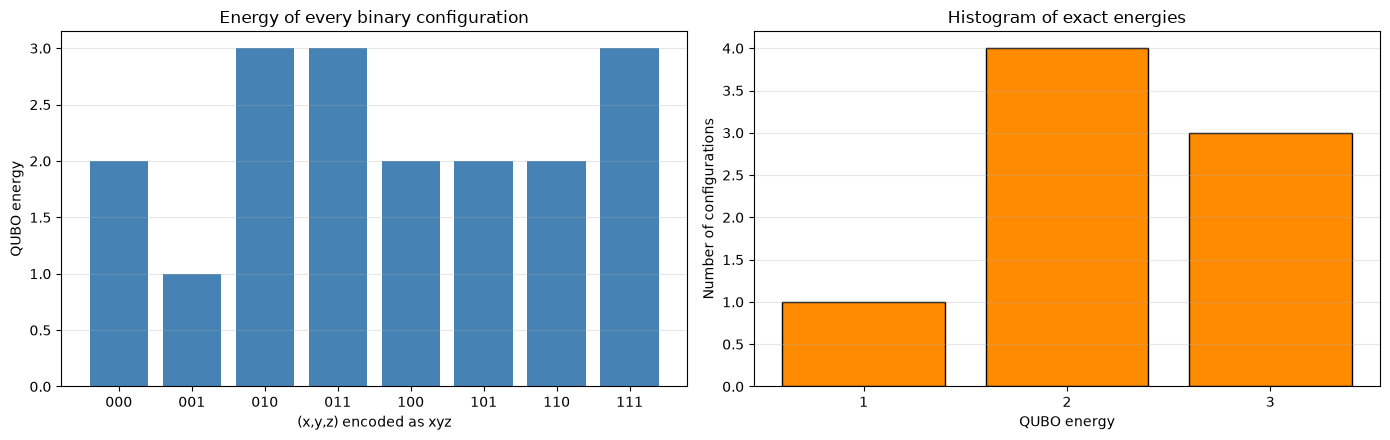

Exact minimum energy: 1
Maximum number of satisfied clauses: 5


In [9]:
def sampleset_dataframe(sampleset):
    rows = []
    for row in sampleset.data(['sample', 'energy', 'num_occurrences']):
        bits = tuple(int(row.sample[name]) for name in variable_names)
        rows.append({
            'configuration': ''.join(map(str, bits)),
            'x': bits[0],
            'y': bits[1],
            'z': bits[2],
            'energy': float(row.energy),
            'satisfied_clauses': 6 - int(round(row.energy)),
            'num_occurrences': int(row.num_occurrences),
        })
    return pd.DataFrame(rows).sort_values('configuration').reset_index(drop=True)

exact_sampleset = ExactSolver().sample(bqm)
exact_table = sampleset_dataframe(exact_sampleset)
display(exact_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(exact_table['configuration'], exact_table['energy'], color='steelblue')
axes[0].set_title('Energy of every binary configuration')
axes[0].set_xlabel('(x,y,z) encoded as xyz')
axes[0].set_ylabel('QUBO energy')
axes[0].set_ylim(bottom=0)
axes[0].grid(axis='y', alpha=0.3)

energy_values = exact_table['energy'].to_numpy()
bins = np.arange(energy_values.min() - 0.5, energy_values.max() + 1.5, 1)
axes[1].hist(energy_values, bins=bins, rwidth=0.8, color='darkorange', edgecolor='black')
axes[1].set_title('Histogram of exact energies')
axes[1].set_xlabel('QUBO energy')
axes[1].set_ylabel('Number of configurations')
axes[1].set_xticks(sorted(set(energy_values)))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

exact_minimum = exact_table['energy'].min()
print(f'Exact minimum energy: {exact_minimum:g}')
print(f'Maximum number of satisfied clauses: {6 - int(exact_minimum)}')

## Interactive simulated annealing

Move the sliders and execute the cell. Each setting starts a new
simulated-annealing experiment. Increasing `num_reads` gives more
independent attempts; increasing `num_sweeps` gives each attempt more time
to relax. The histogram is weighted by the number of times each energy was
observed.

A sample with energy at most `1` certifies that at least five clauses are
satisfied. If the heuristic returns an energy larger than `1`, that does
not prove that the optimum was missed: only the exact enumeration above
provides the global optimum for this small example.

In [12]:
def simulated_annealing_experiment(num_reads=10, num_sweeps=10):
    sampler = SimulatedAnnealingSampler()
    sampleset = sampler.sample(
        bqm,
        num_reads=int(num_reads),
        num_sweeps=int(num_sweeps),
        seed=2026,
    )
    table = sampleset_dataframe(sampleset)
    best_energy = table['energy'].min()

    display(table.sort_values(['energy', 'configuration']))

    fig, ax = plt.subplots(figsize=(7, 4))
    energies = table['energy'].to_numpy()
    occurrences = table['num_occurrences'].to_numpy()
    bins = np.arange(energies.min() - 0.5, energies.max() + 1.5, 1)
    ax.hist(energies, bins=bins, weights=occurrences, rwidth=0.8,
            color='seagreen', edgecolor='black')
    ax.axvline(exact_minimum, color='crimson', linestyle='--',
               label=f'exact minimum = {exact_minimum:g}')
    ax.set_title(f'Simulated-annealing energies: {num_reads} reads, {num_sweeps} sweeps')
    ax.set_xlabel('QUBO energy')
    ax.set_ylabel('Number of sampled configurations')
    ax.set_xticks(sorted(set(energies)))
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'Best sampled energy: {best_energy:g}')
    print(f'Clauses satisfied by the best sample: {6 - int(best_energy)}')
    if best_energy <= exact_minimum:
        print('The experiment found an exact ground state.')
    else:
        print('The experiment did not find the known ground state; this is not a proof of non-optimality.')

widgets.interact(
    simulated_annealing_experiment,
    num_reads=widgets.IntSlider(
        value=10, min=1, max=10, step=1, description='runs / reads'
    )
);

interactive(children=(IntSlider(value=10, description='runs / reads', max=10, min=1), IntSlider(value=10, desc…